# TikTok Climate Action Marketing Analytics

Competition question: **How can marketing analytics help uncover insights to more effectively promote climate actions on TikTok?**

This refined notebook keeps the exploratory notebook's useful logic, but moves repeatable data preparation into `src/tiktok_semantic` and focuses the notebook on insight generation.

## Analysis Focus

1. Which post formats travel furthest?
2. Which climate message themes and action frames earn efficient engagement?
3. Which hashtags and posts point to practical creative recommendations?

The multimodal `summary.txt` files are treated as precomputed video, image, and audio understanding features.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 140)
plt.style.use("seaborn-v0_8-whitegrid")
VIRIDIS = plt.get_cmap("viridis")

PROC = ROOT / "data" / "processed"
CORE = PROC / "core"
ANALYTICS = PROC / "analytics"

## Build Data

Run this once from the repo root if the processed tables are missing:

```powershell
python scripts/build_dataset.py --config configs/sample.yaml
```

In [2]:
manifest = pd.read_csv(PROC / "manifest.csv")
display(manifest)

,table,category,rows,cols,path
0,author_metrics,core,10,9,data\processed\core\author_metrics.parquet
1,authorfavorites,core,200,53,data\processed\core\authorfavorites.parquet
2,authorfollowers,core,2643,5,data\processed\core\authorfollowers.parquet
3,authorfollowers_metrics,core,10,5,data\processed\core\authorfollowers_metrics.parquet
4,authorfollowings,core,531,5,data\processed\core\authorfollowings.parquet
5,authorfollowings_metrics,core,8,5,data\processed\core\authorfollowings_metrics.parquet
6,authorpost_metrics,core,10,15,data\processed\core\authorpost_metrics.parquet
7,authorposts,core,878,56,data\processed\core\authorposts.parquet
8,authors,core,10,31,data\processed\core\authors.parquet
9,comment_intent_summary,analytics,6,4,data\processed\analytics\comment_intent_summary.csv


In [3]:
posts = pd.read_parquet(CORE / "posts_enriched.parquet")
summaries = pd.read_parquet(CORE / "posts_summaries.parquet")
hashtags = pd.read_csv(ANALYTICS / "hashtag_performance.csv")
content_type = pd.read_csv(ANALYTICS / "content_type_performance.csv")
themes = pd.read_csv(ANALYTICS / "theme_performance.csv")
recommendations = pd.read_csv(ANALYTICS / "messaging_recommendations.csv")
region_perf = pd.read_csv(ANALYTICS / "region_performance.csv")
comment_intents = pd.read_csv(ANALYTICS / "comment_intent_summary.csv")
post_comment_intents = pd.read_csv(ANALYTICS / "post_comment_intents.csv")
creator_leverage = pd.read_csv(ANALYTICS / "creator_leverage.csv")
creator_bridge = pd.read_csv(ANALYTICS / "creator_bridge_metrics.csv") if (ANALYTICS / "creator_bridge_metrics.csv").exists() else pd.DataFrame()
semantic_clusters = pd.read_csv(ANALYTICS / "semantic_clusters.csv") if (ANALYTICS / "semantic_clusters.csv").exists() else pd.DataFrame()
semantic_cluster_perf = pd.read_csv(ANALYTICS / "semantic_cluster_performance.csv") if (ANALYTICS / "semantic_cluster_performance.csv").exists() else pd.DataFrame()
comment_sentiment = pd.read_csv(ANALYTICS / "comment_sentiment_summary.csv") if (ANALYTICS / "comment_sentiment_summary.csv").exists() else pd.DataFrame()
post_comment_sentiment = pd.read_csv(ANALYTICS / "post_comment_sentiment.csv") if (ANALYTICS / "post_comment_sentiment.csv").exists() else pd.DataFrame()

print(f"Posts: {len(posts):,}")
print(f"Captured comments: {int(posts['n_comments_captured'].sum()):,}")
print(f"Video summary rows: {len(summaries):,}")

Posts: 10
Captured comments: 710
Video summary rows: 10


## Dataset Snapshot

In [4]:
snapshot_cols = [
    "video_id", "date", "region", "content_type", "primary_theme", "action_frame",
    "mood_label", "play_count", "share_count", "comment_count", "eng_per_1k_views",
    "overall_narrative_message",
]
display(posts[[c for c in snapshot_cols if c in posts.columns]].sort_values("play_count", ascending=False))

,video_id,date,region,content_type,primary_theme,action_frame,mood_label,play_count,share_count,comment_count,eng_per_1k_views,overall_narrative_message
1,7183890636540480774,2023-01-02,CA,video,solutions_action,awareness_only,urgent_alarm,2599101,11707,4451,1231.239956,The video's narrative is a powerful environmental and appreciative message. It starts by acknowledging the human tendency to be captivat...
3,7272820833368739114,2023-08-29,US,video,education_awareness,individual_action,humorous_ironic,944967,4843,2379,1092.164065,The video aims to highlight the irony and cognitive dissonance of an individual denying climate change and global warming while simultan...
2,7190746443144056069,2023-01-20,GB,video,solutions_action,policy_systemic,humorous_ironic,889648,6979,3549,1069.064394,"The video, as presented by ""Rebel News,"" aims to portray Greta Thunberg as evasive, insincere, and unable or unwilling to engage with cr..."
4,7379384416914705707,2024-06-11,US,images_audio,solutions_action,collective_action,urgent_alarm,783470,487,1205,1062.555044,The overall narrative is a strong advocacy for prioritizing and expanding public transportation systems. It argues that public transit i...
0,7183855666618961195,2023-01-02,US,images_music,solutions_action,individual_action,hopeful_empowering,212341,1673,598,1270.456483,"The sequence presents a comprehensive guide on ""how to live an eco-lifestyle in 2023."" It starts with simple, individual actions one can..."
6,7507756166869568810,2025-05-23,US,images_music,climate_impacts,awareness_only,urgent_alarm,1047,0,1,1043.935053,"* The visual sequence presents a clear, educational narrative about climate change. It begins by introducing the concept with contrast..."
5,7447922155112680734,2024-12-13,US,images_music,climate_impacts,awareness_only,urgent_alarm,960,0,0,1046.875000,The sequence tells a clear and alarming story about the escalating climate crisis. It begins by stating that 2024 is set to break climat...
8,7508122368439586050,2025-05-24,GB,video,climate_impacts,individual_action,urgent_alarm,471,1,0,1078.556263,"The overall narrative is a powerful critique of a global system where the pursuit of profit and excessive consumption by a few (the ""win..."
9,7508164065458457902,2025-05-24,US,images_audio,solutions_action,individual_action,humorous_ironic,343,0,0,1005.830904,"* The image is a piece of critical, derogatory, and politically charged satire or propaganda. It aims to discredit Greta Thunberg and,..."
7,7508046635176332552,2025-05-24,GB,video,climate_impacts,policy_systemic,urgent_alarm,0,0,4,0.000000,"The video's narrative is to inform viewers about the primary contributors to global carbon emissions, identifying the top five countries..."


## Insight 1: Format Matters

Compare video-only, image-plus-music, and image-plus-audio posts. Median views and engagement per 1k views separate reach from efficiency.

,content_type,posts,median_views,median_eng_per_1k,mean_shares,mean_comments
0,video,5,889648.0,1078.556263,4706.000000,2076.600000
1,images_music,3,1047.0,1046.875000,557.666667,199.666667
2,images_audio,2,391906.5,1034.192974,243.500000,602.500000


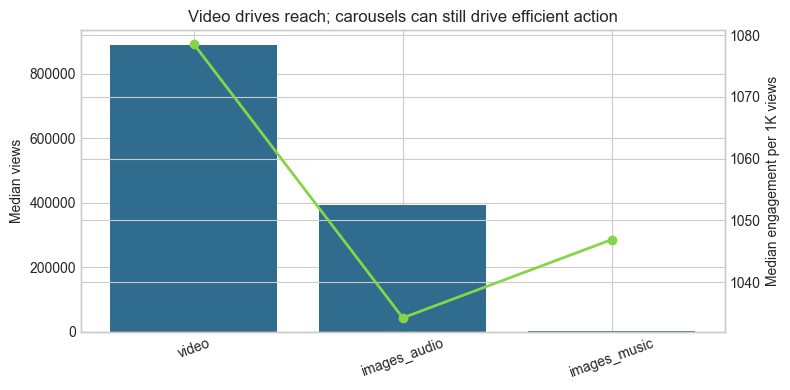

In [5]:
display(content_type)
fig, ax1 = plt.subplots(figsize=(8, 4))
plot_df = content_type.sort_values("median_views", ascending=False)
ax1.bar(plot_df["content_type"], plot_df["median_views"], color=VIRIDIS(0.35), label="Median views")
ax1.set_ylabel("Median views")
ax1.tick_params(axis="x", rotation=20)
ax2 = ax1.twinx()
ax2.plot(plot_df["content_type"], plot_df["median_eng_per_1k"], color=VIRIDIS(0.82), marker="o", linewidth=2, label="Engagement per 1K")
ax2.set_ylabel("Median engagement per 1K views")
ax1.set_title("Video drives reach; carousels can still drive efficient action")
fig.tight_layout()

## Insight 2: Message Frames

`primary_theme`, `action_frame`, and `mood_label` are rule-based labels derived from Gemini's multimodal summaries. They are intentionally lightweight so the analysis stays reproducible.

,primary_theme,action_frame,mood_label,posts,median_views,median_eng_per_1k,mean_shares,mean_comments,total_shares
0,solutions_action,individual_action,hopeful_empowering,1,212341.0,1270.456483,1673.0,598.0,1673
1,solutions_action,awareness_only,urgent_alarm,1,2599101.0,1231.239956,11707.0,4451.0,11707
2,education_awareness,individual_action,humorous_ironic,1,944967.0,1092.164065,4843.0,2379.0,4843
3,climate_impacts,individual_action,urgent_alarm,1,471.0,1078.556263,1.0,0.0,1
4,solutions_action,policy_systemic,humorous_ironic,1,889648.0,1069.064394,6979.0,3549.0,6979
5,solutions_action,collective_action,urgent_alarm,1,783470.0,1062.555044,487.0,1205.0,487
6,climate_impacts,awareness_only,urgent_alarm,2,1003.5,1045.405026,0.0,0.5,0
7,solutions_action,individual_action,humorous_ironic,1,343.0,1005.830904,0.0,0.0,0
8,climate_impacts,policy_systemic,urgent_alarm,1,0.0,0.000000,0.0,4.0,0


,primary_theme,action_frame,content_type,posts,median_views,median_eng_per_1k,median_shares,views_rank_pct,eng_rank_pct,share_rank_pct,opportunity_score
0,solutions_action,awareness_only,video,1,2599101.0,1231.239956,11707.0,1.000000,0.833333,1.000000,0.933
1,education_awareness,individual_action,video,1,944967.0,1092.164065,4843.0,0.833333,0.666667,0.666667,0.725
2,solutions_action,policy_systemic,video,1,889648.0,1069.064394,6979.0,0.666667,0.500000,0.833333,0.642
3,solutions_action,individual_action,images_music,1,212341.0,1270.456483,1673.0,0.333333,1.000000,0.500000,0.642
4,solutions_action,collective_action,images_audio,1,783470.0,1062.555044,487.0,0.500000,0.333333,0.333333,0.392
5,climate_impacts,awareness_only,images_music,1,1047.0,1043.935053,0.0,0.166667,0.166667,0.166667,0.167


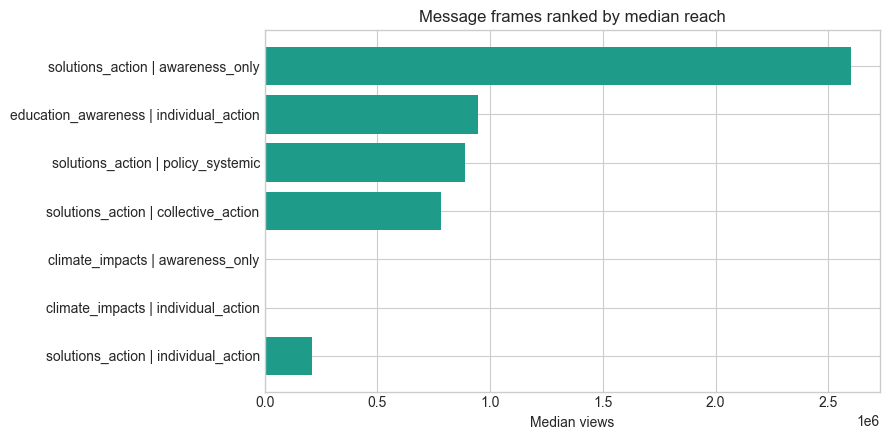

In [6]:
display(themes)
display(recommendations.head(10))
fig, ax = plt.subplots(figsize=(9, 4.5))
plot_df = themes.sort_values("median_views", ascending=True).tail(8)
labels = plot_df["primary_theme"] + " | " + plot_df["action_frame"]
ax.barh(labels, plot_df["median_views"], color=VIRIDIS(0.55))
ax.set_title("Message frames ranked by median reach")
ax.set_xlabel("Median views")
fig.tight_layout()

## Insight 3: Hashtag Opportunities

In [7]:
display(hashtags.head(20))
display(hashtags.query("posts >= 2").sort_values("median_eng_per_1k", ascending=False).head(15))

,hashtag,posts,median_views,mean_views,median_eng_per_1k,total_shares,total_comments
0,#climatechange,9,212341.0,6.034779e+05,1069.064394,25690,12186
1,#fyp,5,1047.0,7.091858e+05,1078.556263,16551,6831
2,#climatecrisis,5,471.0,5.642000e+02,1043.935053,1,5
3,#globalwarming,4,715.5,2.365995e+05,1062.715632,4844,2383
4,#ecofriendly,3,212341.0,3.322860e+05,1062.555044,2160,1804
5,#sustainability,3,960.0,2.614767e+05,1046.875000,487,1209
6,#foryou,2,106342.0,1.063420e+05,1138.143693,1673,598
7,#trump,2,407.0,4.070000e+02,1042.193584,1,0
8,#climateaction,2,695.0,6.950000e+02,1024.882978,0,1
9,#saveourplanet,2,480.0,4.800000e+02,523.437500,0,4


,hashtag,posts,median_views,mean_views,median_eng_per_1k,total_shares,total_comments
6,#foryou,2,106342.0,106342.000000,1138.143693,1673,598
1,#fyp,5,1047.0,709185.800000,1078.556263,16551,6831
0,#climatechange,9,212341.0,603477.888889,1069.064394,25690,12186
3,#globalwarming,4,715.5,236599.500000,1062.715632,4844,2383
4,#ecofriendly,3,212341.0,332286.000000,1062.555044,2160,1804
5,#sustainability,3,960.0,261476.666667,1046.875000,487,1209
2,#climatecrisis,5,471.0,564.200000,1043.935053,1,5
7,#trump,2,407.0,407.000000,1042.193584,1,0
8,#climateaction,2,695.0,695.000000,1024.882978,0,1
9,#saveourplanet,2,480.0,480.000000,523.437500,0,4


## Deep-Dive 1: Regions and Format Reach

Use region and format as controls before making creative claims. In this sample, region mainly reflects the small set of selected posts, so treat it as descriptive rather than causal.

In [8]:
display(region_perf)
display(content_type)

,region,posts,total_views,median_views,total_shares,total_comments,median_eng_per_1k
0,CA,1,2599101,2599101.0,11707,4451,1231.239956
1,US,6,1943128,106694.0,7003,4183,1054.715022
2,GB,3,890119,471.0,6980,3553,1069.064394


,content_type,posts,median_views,median_eng_per_1k,mean_shares,mean_comments
0,video,5,889648.0,1078.556263,4706.000000,2076.600000
1,images_music,3,1047.0,1046.875000,557.666667,199.666667
2,images_audio,2,391906.5,1034.192974,243.500000,602.500000


## Deep-Dive 2: Audience Response From Comments

Comment intent is a lightweight rule-based read on whether viewers are reacting generally, asking questions, expressing barriers, signalling action, showing support, or pushing back. This is useful for campaign planning because it tells us which follow-up content can convert attention into action.

,rough_intent,comments,avg_comment_likes,median_mins_since_post
0,general_reaction,407,117.402948,16449.683333
1,barrier_or_constraint,116,20.879310,30048.866667
2,action_oriented,100,29.010000,58962.991667
3,info_question,42,248.071429,3396.725000
4,support_affect,42,7.523810,26300.358333
5,skeptic_or_counter,3,3.666667,95190.866667


,video_id,captured_comments,avg_comment_likes,early_comments_60m,top_comment_intent,title,play_count,comment_count,share_count,eng_per_1k_views
0,7183890636540480774,200,83.200000,2,general_reaction,"Its not to late, but if we dont act now it will be. She needs us 🌍 ❤️ #avatar2 #climatechange #pollution #avatarwayofwater #fyp",2599101,4451,11707,1231.239956
1,7183855666618961195,200,16.520000,8,general_reaction,Together let’s save our only home. 🌎 #ecotokcentral #ecolifestyle #ecofriendly #climatechange #lettheearthbreathe #savetheearth #foryou,212341,598,1673,1270.456483
2,7379384416914705707,200,13.470000,0,general_reaction,Public transit >> cars How often do you take public transportation? #publictransportation #Sustainability #sustainableliving #ecofriend...,783470,1205,487,1062.555044
3,7272820833368739114,63,407.650794,18,general_reaction,We talked to this guy on a record-setting hot day at the GOP Debate. #fyp #gopdebate #milwuakee #climatechange #globalwarming #interview...,944967,2379,4843,1092.164065
4,7190746443144056069,42,369.642857,1,general_reaction,#davos #rebelnews #climatechange #gretathunberg #wef,889648,3549,6979,1069.064394
5,7508164065458457902,3,1.666667,0,general_reaction,#fyp #fypシ #foryour #foryou #foryourpage #foryoupage #fypagw #for viral #viralvideo #viraltiktok #veryviral #blowthisup #likes #like #he...,343,0,0,1005.830904
6,7507756166869568810,1,1.000000,1,general_reaction,You may think climate change isn’t a big deal but it can affect your life sooner than you think. #climatecrisis #climatechangeisreal #aw...,1047,1,0,1043.935053
7,7508046635176332552,1,1.000000,0,general_reaction,"🌍 These are the Top 5 Carbon Emitting Countries — and their impact on the planet is massive. The race to reduce emissions is on, but som...",0,4,0,0.000000


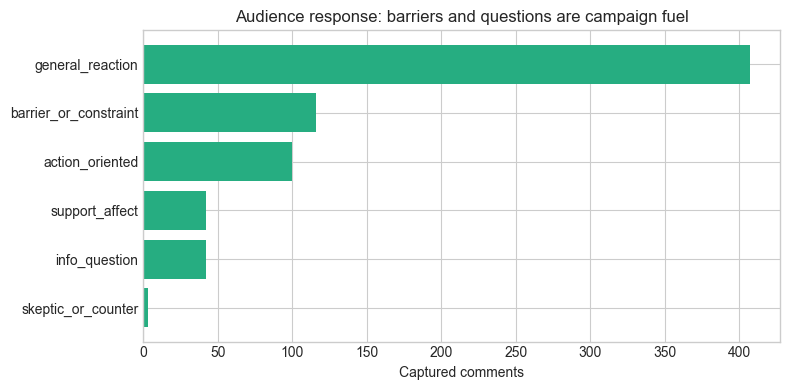

In [9]:
display(comment_intents)
display(post_comment_intents.head(10))
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = comment_intents.sort_values("comments", ascending=True)
ax.barh(plot_df["rough_intent"], plot_df["comments"], color=VIRIDIS(0.62))
ax.set_title("Audience response: barriers and questions are campaign fuel")
ax.set_xlabel("Captured comments")
fig.tight_layout()

## Deep-Dive 3: Creator Leverage

For marketing activation, follower count is not enough. `views_per_follower_history` helps identify creators whose historical content overperforms relative to their audience size.

,video_id,author_id,author_unique_id,author_nickname,creator_scale,stats_followerCount,stats_heartCount,posts_total,active_months,posts_per_month,avg_play,avg_share,eng_per_1k_views_mean,views_per_follower_history
0,7183890636540480774,7054621718408954885,iphoneuserr627739291,Youdontknowme,micro,5979,533076,1,1,1.000000,2.599330e+06,11707.000000,1231.202656,434.743268
1,7507756166869568810,7467304784644031534,glow_greenn,glow_greenn,nano,158,11570,8,3,2.666667,2.049700e+04,494.750000,1088.626107,129.727848
2,7508122368439586050,7435278573911671841,geminibluue,geminiblu,nano,19,1368,10,4,2.500000,1.161400e+03,6.200000,1137.674676,61.126316
3,7508164065458457902,7504513367894492203,footlongjaredfogle,FootlongFogle,nano,7,200,26,1,26.000000,3.537308e+02,0.807692,1022.263203,50.532967
4,7447922155112680734,7079884576029475882,thatreporterliz,Thatreporter,nano,603,33484,23,9,2.555556,1.213583e+04,166.173913,1067.568103,20.125748
5,7508046635176332552,6841264715379131398,theenviropreneurdotcom,Enviropreneur,nano,86,679,59,11,5.363636,6.059492e+02,1.220339,1058.197913,7.045920
6,7379384416914705707,6742912676903568389,zerowastestore,ZeroWasteStore,mid,27703,4196549,200,9,22.222222,1.282026e+05,741.935000,1061.710488,4.627753
7,7183855666618961195,6993899054099432453,ecotokcentral,Jack,macro,331497,15935489,151,33,4.575758,5.679304e+05,2457.940397,1201.430784,1.713229
8,7272820833368739114,6724659169629340678,thegoodliars,The Good Liars,mega,2400796,157099910,200,26,7.692308,2.249106e+06,16165.295000,1086.182684,0.936817
9,7190746443144056069,7014974313570042886,y.a.s_q,Yas Qureshi,mid,30514,1050520,200,14,14.285714,5.440080e+03,42.130000,1085.955607,0.178281


,video_id,author_id,author_unique_id,author_nickname,network_degree,network_betweenness,component_id,component_size,captured_followers,captured_followings,stats_followerCount,stats_heartCount,stats_videoCount,play_count,share_count,comment_count,eng_per_1k_views,bridge_score
0,7379384416914705707,6742912676903568389,zerowastestore,ZeroWasteStore,796,0.240239,1,4,398,398,27703,4196549,814,783470,487,1205,1062.555044,0.870
1,7272820833368739114,6724659169629340678,thegoodliars,The Good Liars,424,0.017967,3,1,398,26,2400796,157099910,745,944967,4843,2379,1092.164065,0.775
2,7447922155112680734,7079884576029475882,thatreporterliz,Thatreporter,443,0.136991,1,4,400,50,603,33484,23,960,0,0,1046.875000,0.760
3,7183890636540480774,7054621718408954885,iphoneuserr627739291,Youdontknowme,393,0.115647,1,4,392,1,5979,533076,1,2599101,11707,4451,1231.239956,0.750
4,7183855666618961195,6993899054099432453,ecotokcentral,Jack,398,0.015828,0,1,398,0,331497,15935489,151,212341,1673,598,1270.456483,0.735
5,7190746443144056069,7014974313570042886,y.a.s_q,Yas Qureshi,388,0.015042,2,1,388,0,30514,1050520,835,889648,6979,3549,1069.064394,0.550
6,7507756166869568810,7467304784644031534,glow_greenn,glow_greenn,159,0.002517,4,1,159,3,158,11570,8,1047,0,1,1043.935053,0.335
7,7508164065458457902,7504513367894492203,footlongjaredfogle,FootlongFogle,38,0.011905,1,4,8,35,7,200,38,343,0,0,1005.830904,0.280
8,7508122368439586050,7435278573911671841,geminibluue,geminiblu,28,0.000076,6,1,18,14,19,1368,10,471,1,0,1078.556263,0.230
9,7508046635176332552,6841264715379131398,theenviropreneurdotcom,Enviropreneur,88,0.000767,5,1,84,4,86,679,59,0,0,4,0.000000,0.215


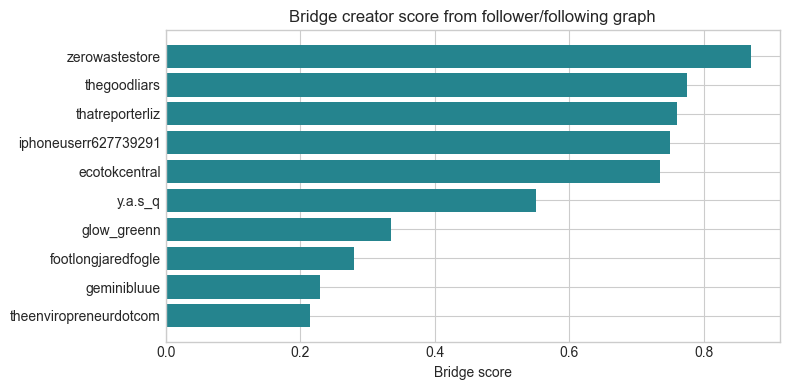

In [10]:
display(creator_leverage.head(15))
display(creator_bridge.head(15) if not creator_bridge.empty else creator_bridge)
if not creator_bridge.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    plot_df = creator_bridge.sort_values("bridge_score", ascending=True).tail(10)
    ax.barh(plot_df["author_unique_id"], plot_df["bridge_score"], color=VIRIDIS(0.45))
    ax.set_title("Bridge creator score from follower/following graph")
    ax.set_xlabel("Bridge score")
    fig.tight_layout()

## Deep-Dive 4: Organic Narrative Clusters

Run `python scripts/deep_dive_nlp.py --config configs/sample.yaml` before this section. The clustering uses summary text to discover narrative groups beyond the hand-built theme labels.

,cluster_id,cluster_name,posts,median_views,total_views,median_eng_per_1k,total_shares,total_comments
0,1,earth / video / greta,5,889648.0,4434187,1078.556263,23530,10383
1,0,image / audio / climate,5,1047.0,998161,1046.875000,2160,1804


,video_id,content_type,cluster_id,cluster_name,is_cluster_representative
0,7183855666618961195,images_music,0,image / audio / climate,False
1,7183890636540480774,video,1,earth / video / greta,False
2,7190746443144056069,video,1,earth / video / greta,False
3,7272820833368739114,video,1,earth / video / greta,False
4,7379384416914705707,images_audio,0,image / audio / climate,False
5,7447922155112680734,images_music,0,image / audio / climate,True
6,7507756166869568810,images_music,0,image / audio / climate,False
7,7508046635176332552,video,1,earth / video / greta,True
8,7508122368439586050,video,1,earth / video / greta,False
9,7508164065458457902,images_audio,0,image / audio / climate,False


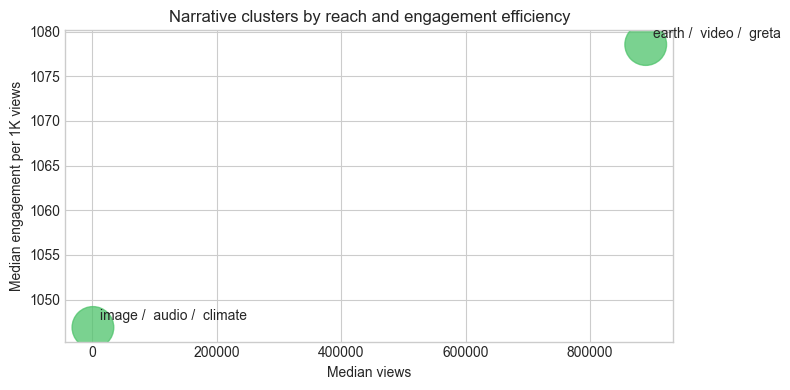

In [11]:
display(semantic_cluster_perf)
display(semantic_clusters[["video_id", "content_type", "cluster_id", "cluster_name", "is_cluster_representative"]] if not semantic_clusters.empty else semantic_clusters)
if not semantic_cluster_perf.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.scatter(
        semantic_cluster_perf["median_views"],
        semantic_cluster_perf["median_eng_per_1k"],
        s=semantic_cluster_perf["posts"] * 180,
        color=VIRIDIS(0.72),
        alpha=0.75,
    )
    for _, r in semantic_cluster_perf.iterrows():
        ax.annotate(str(r["cluster_name"])[:28], (r["median_views"], r["median_eng_per_1k"]), xytext=(5, 5), textcoords="offset points")
    ax.set_title("Narrative clusters by reach and engagement efficiency")
    ax.set_xlabel("Median views")
    ax.set_ylabel("Median engagement per 1K views")
    fig.tight_layout()

## Deep-Dive 5: Comment Sentiment and Emotion

This dependency-light pass separates broad sentiment from useful emotional signals such as confusion, anxiety, support, hope, and anger. For the final version, these columns can be replaced with transformer model outputs while preserving the same table structure.

,sentiment_label,emotion_label,comments,avg_comment_likes,median_mins_since_post
0,neutral,neutral,409,114.586797,15803.983333
1,neutral,confusion,136,93.205882,37856.816667
2,positive,support,37,8.081081,25297.966667
3,positive,hope,33,8.575758,29443.250000
4,neutral,hope,24,21.458333,68839.850000
5,positive,neutral,23,50.086957,27302.750000
6,positive,confusion,15,10.600000,47213.683333
7,negative,neutral,12,2.500000,58423.025000
8,negative,anger,6,2.166667,751.708333
9,neutral,support,5,6.000000,5586.866667


,video_id,comments_scored,avg_sentiment_score,pct_positive,pct_negative,top_emotion,title,play_count,comment_count,share_count,eng_per_1k_views
0,7183855666618961195,200,0.071213,0.220000,0.030000,neutral,Together let’s save our only home. 🌎 #ecotokcentral #ecolifestyle #ecofriendly #climatechange #lettheearthbreathe #savetheearth #foryou,212341,598,1673,1270.456483
1,7183890636540480774,200,0.060052,0.185000,0.035000,neutral,"Its not to late, but if we dont act now it will be. She needs us 🌍 ❤️ #avatar2 #climatechange #pollution #avatarwayofwater #fyp",2599101,4451,11707,1231.239956
2,7379384416914705707,200,0.026119,0.120000,0.030000,neutral,Public transit >> cars How often do you take public transportation? #publictransportation #Sustainability #sustainableliving #ecofriend...,783470,1205,487,1062.555044
3,7272820833368739114,63,0.005493,0.063492,0.079365,neutral,We talked to this guy on a record-setting hot day at the GOP Debate. #fyp #gopdebate #milwuakee #climatechange #globalwarming #interview...,944967,2379,4843,1092.164065
4,7190746443144056069,42,-0.006604,0.000000,0.023810,neutral,#davos #rebelnews #climatechange #gretathunberg #wef,889648,3549,6979,1069.064394
5,7508164065458457902,3,0.000000,0.000000,0.000000,neutral,#fyp #fypシ #foryour #foryou #foryourpage #foryoupage #fypagw #for viral #viralvideo #viraltiktok #veryviral #blowthisup #likes #like #he...,343,0,0,1005.830904
6,7508046635176332552,1,0.000000,0.000000,0.000000,neutral,"🌍 These are the Top 5 Carbon Emitting Countries — and their impact on the planet is massive. The race to reduce emissions is on, but som...",0,4,0,0.000000
7,7507756166869568810,1,-0.353553,0.000000,1.000000,anger,You may think climate change isn’t a big deal but it can affect your life sooner than you think. #climatecrisis #climatechangeisreal #aw...,1047,1,0,1043.935053


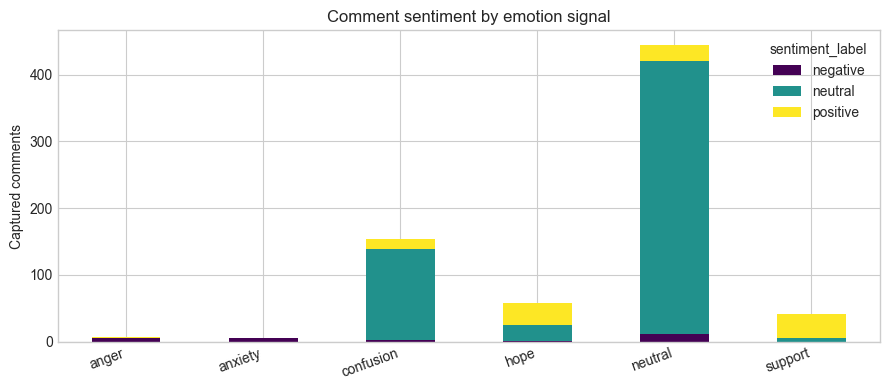

In [12]:
display(comment_sentiment)
display(post_comment_sentiment.head(10))
if not comment_sentiment.empty:
    pivot = comment_sentiment.pivot_table(index="emotion_label", columns="sentiment_label", values="comments", aggfunc="sum", fill_value=0)
    ax = pivot.plot(kind="bar", stacked=True, figsize=(9, 4), colormap="viridis")
    ax.set_title("Comment sentiment by emotion signal")
    ax.set_xlabel("")
    ax.set_ylabel("Captured comments")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

## Creative Recommendations Template

Use the table below as the evidence base for final presentation claims. Good claims should link a creative choice to a marketing outcome, for example: format, theme, action frame, mood, reach, shareability, or engagement efficiency.

In [13]:
cols = ["primary_theme", "action_frame", "content_type", "posts", "median_views", "median_eng_per_1k", "median_shares", "opportunity_score"]
display(recommendations[cols])

,primary_theme,action_frame,content_type,posts,median_views,median_eng_per_1k,median_shares,opportunity_score
0,solutions_action,awareness_only,video,1,2599101.0,1231.239956,11707.0,0.933
1,education_awareness,individual_action,video,1,944967.0,1092.164065,4843.0,0.725
2,solutions_action,policy_systemic,video,1,889648.0,1069.064394,6979.0,0.642
3,solutions_action,individual_action,images_music,1,212341.0,1270.456483,1673.0,0.642
4,solutions_action,collective_action,images_audio,1,783470.0,1062.555044,487.0,0.392
5,climate_impacts,awareness_only,images_music,1,1047.0,1043.935053,0.0,0.167
